<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE338/blob/main/LAB/Lab3/lab3_classification_6606520168_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# 1) Install & Import Libraries
# =========================
!pip install geopandas rasterio folium geemap earthengine-api shapely pyproj fiona rtree scikit-learn -q

import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import ee
import geemap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
from sklearn.model_selection import train_test_split

In [ ]:
# =========================
# 2) Mount Drive
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# 3) Load Sentinel-2 Image
# =========================
tif_path = '/content/drive/MyDrive/GE338/LAB3/TIF/S2_allbands.tif'
img_src = rasterio.open(tif_path)

blue = img_src.read(2)
green = img_src.read(3)
red = img_src.read(4)
nir = img_src.read(8)

# indices
ndvi = (nir - red) / (nir + red + 1e-10)
ndwi = (green - nir) / (green + nir + 1e-10)

# stack
stack = np.stack([blue, green, red, nir, ndvi, ndwi], axis=-1)

print("Image shape:", stack.shape)

Image shape: (2139, 2500, 6)


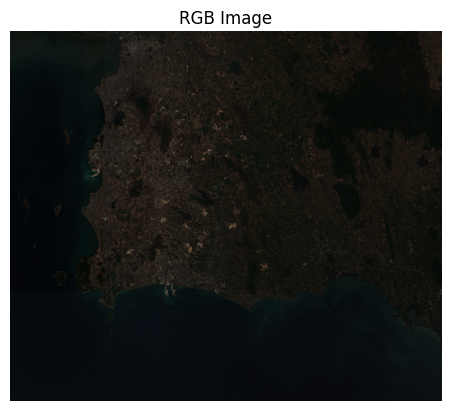

In [ ]:
# =========================
# 4) RGB Visualization
# =========================
rgb = np.dstack([red, green, blue])

plt.imshow(rgb / np.max(rgb))
plt.title("RGB Image")
plt.axis('off')
plt.show()

In [ ]:
# =========================
# 5) Load RAW Label
# =========================
label_path = '/content/drive/MyDrive/GE338/label_5class_final.tif'

label_src = rasterio.open(label_path)
labels = label_src.read(1)

print("Unique classes (original):", np.unique(labels))

Unique classes (original): [0 1 4 6 7]


In [ ]:
# =========================
# 6) Filter Target Classes
# =========================
# water(0), trees(1), crops(4), built(6), bare(7)

valid_classes = [0, 1, 4, 6, 7]

mask_valid = np.isin(labels, valid_classes)

# ✅ ใช้ -1 เป็น background (สำคัญ)
labels = np.where(mask_valid, labels, -1)

print("Classes after filter:", np.unique(labels))


Classes after filter: [0 1 4 6 7]


In [ ]:
# =========================
# 7) Resize Label
# =========================
from skimage.transform import resize

labels_resized = resize(
    labels,
    (stack.shape[0], stack.shape[1]),
    order=0,
    preserve_range=True,
    anti_aliasing=False
).astype(labels.dtype)


In [ ]:
# =========================
# 8) Prepare Data
# =========================
X = stack.reshape(-1, stack.shape[-1])
y = labels_resized.flatten()

# remove background
mask = y != -1
X = X[mask]
y = y[mask]

print("Training data:", X.shape, y.shape)

Training data: (5347500, 6) (5347500,)


In [ ]:
# =========================
# 9) Class Distribution
# =========================
unique, counts = np.unique(y, return_counts=True)

print("\nClass distribution:")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")


Class distribution:
Class 0: 3520227
Class 1: 1406878
Class 4: 23697
Class 6: 389153
Class 7: 7545


In [ ]:
# =========================
# 10) Encode Labels (0–4)
# =========================
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

print("Encoded classes:", np.unique(y))

Encoded classes: [0 1 2 3 4]


In [ ]:
# =========================
# 11) Split Data
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# =========================
# 12) Train Model
# =========================
from sklearn.ensemble import RandomForestClassifier
# =========================
# Sampling
# =========================
np.random.seed(42)
idx = np.random.choice(len(X), 100000, replace=False)

X_sample = X[idx]
y_sample = y[idx]

# =========================
# Train/Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

# =========================
# Train RF
# =========================
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [ ]:
# =========================
# 13) Evaluate Model
# =========================
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

kappa = cohen_kappa_score(y_test, y_pred)
print("Kappa:", kappa)


Accuracy: 0.8257

Confusion Matrix:
 [[11734  1251     0   295     3]
 [ 1044  4042     0    34     0]
 [   69    20     0     1     0]
 [  673    74     0   737     0]
 [   21     1     0     0     1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.88      0.87     13283
           1       0.75      0.79      0.77      5120
           2       0.00      0.00      0.00        90
           3       0.69      0.50      0.58      1484
           4       0.25      0.04      0.07        23

    accuracy                           0.83     20000
   macro avg       0.51      0.44      0.46     20000
weighted avg       0.82      0.83      0.82     20000

Kappa: 0.6349065702505818


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# =========================
# 14) Feature Importance
# =========================
features = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'NDWI']

for f, imp in zip(features, rf.feature_importances_):
    print(f"{f}: {imp:.4f}")

Blue: 0.1425
Green: 0.0717
Red: 0.1103
NIR: 0.2370
NDVI: 0.1704
NDWI: 0.2682


In [ ]:
# =========================
# 15) Predict Map
# =========================
pred = rf.predict(X)

pred_map = np.zeros(labels_resized.shape)
pred_map.reshape(-1)[mask] = pred

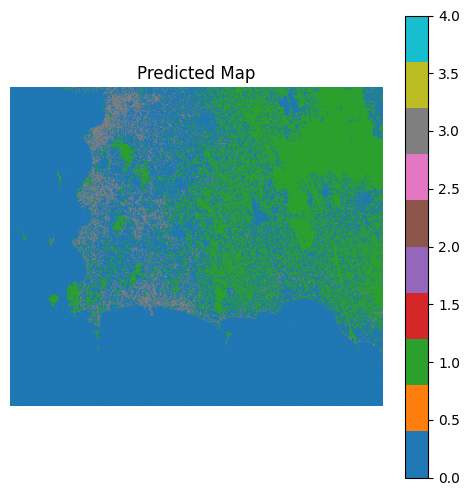

In [ ]:
# =========================
# 16) Visualization
# =========================
small_pred = pred_map[::5, ::5]

plt.figure(figsize=(6,6))
plt.imshow(small_pred, cmap='tab10')
plt.colorbar()
plt.title("Predicted Map")
plt.axis('off')
plt.show()

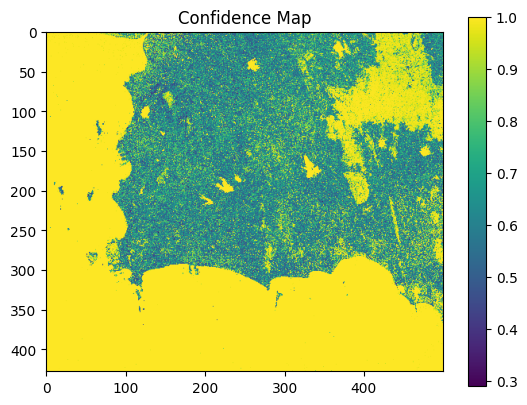

In [ ]:
# =========================
# 17) Confidence Map
# =========================
probs = rf.predict_proba(X)
confidence = np.max(probs, axis=1)

conf_map = np.zeros(labels_resized.shape)
conf_map.reshape(-1)[mask] = confidence

small_conf = conf_map[::5, ::5]

plt.imshow(small_conf, cmap='viridis')
plt.colorbar()
plt.title("Confidence Map")
plt.show()

In [ ]:
# =========================
# KMeans Clustering
# =========================
from sklearn.cluster import KMeans

# 🔥 ใช้ sample เพื่อลด RAM (สำคัญ)
np.random.seed(42)
idx = np.random.choice(len(X), 100000, replace=False)

X_sample = X[idx]

# train model
kmeans = KMeans(
    n_clusters=5,      # เท่าจำนวน class
    random_state=42,
    n_init=10
)

kmeans.fit(X_sample)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
# =========================
# Predict clusters
# =========================
kmeans_pred = kmeans.predict(X)

In [ ]:
# =========================
# Create KMeans Map
# =========================
kmeans_map = np.zeros(labels_resized.shape)
kmeans_map.reshape(-1)[mask] = kmeans_pred

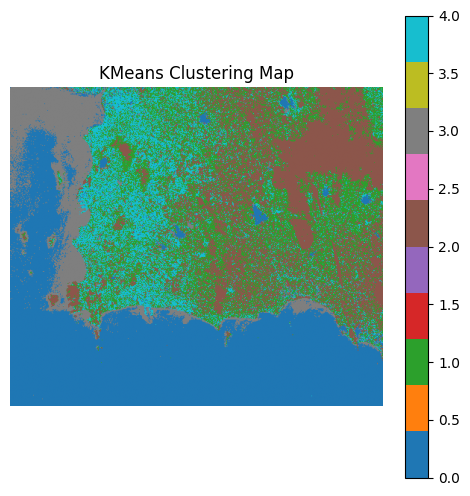

In [ ]:
# =========================
# Visualization
# =========================
small_kmeans = kmeans_map[::5, ::5]

plt.figure(figsize=(6,6))
plt.imshow(small_kmeans, cmap='tab10')
plt.colorbar()
plt.title("KMeans Clustering Map")
plt.axis('off')
plt.show()

In [ ]:
# ดูว่า cluster ไหนใกล้ class อะไร
import pandas as pd

df = pd.DataFrame({
    'cluster': kmeans_pred,
    'true': y[:len(kmeans_pred)]  # ต้อง align ขนาด
})

print(pd.crosstab(df['cluster'], df['true']))

true           0       1      2       3     4
cluster                                      
0        1845208    1406     33   10932   283
1         580876  393676  11421  135447   616
2         257215  954680   4296   23118    62
3         501151     956      6    1583    82
4         335777   56160   7941  218073  6502


In [ ]:
# =========================
# 0) Setup Folder
# =========================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_path = "/content/drive/MyDrive/GE338/GE338-Lab-3"
fig_path = os.path.join(base_path, "figures")
os.makedirs(fig_path, exist_ok=True)


# =========================
# 1) Random Forest Metrics
# =========================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score

rf_acc = accuracy_score(y_test, y_pred)
rf_kappa = cohen_kappa_score(y_test, y_pred)

rf_report = classification_report(y_test, y_pred, output_dict=True)
rf_df = pd.DataFrame(rf_report).transpose()

rf_df.to_csv(os.path.join(fig_path, "rf_classification_report.csv"))


# =========================
# 2) KMeans Evaluation (approximate)
# =========================
# ⚠️ ต้อง align ขนาด
kmeans_pred_sample = kmeans.predict(X_test)

km_acc = accuracy_score(y_test, kmeans_pred_sample)
km_kappa = cohen_kappa_score(y_test, kmeans_pred_sample)

km_report = classification_report(y_test, kmeans_pred_sample, output_dict=True)
km_df = pd.DataFrame(km_report).transpose()

km_df.to_csv(os.path.join(fig_path, "kmeans_classification_report.csv"))


# =========================
# 3) Confusion Matrix Plot
# =========================
def save_confusion_matrix(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    path = os.path.join(fig_path, f"{name}_confusion_matrix.png")
    plt.savefig(path, dpi=300)
    plt.close()

    print("Saved:", path)

save_confusion_matrix(y_test, y_pred, "RandomForest")
save_confusion_matrix(y_test, kmeans_pred_sample, "KMeans")


# =========================
# 4) Summary Table
# =========================
summary = pd.DataFrame({
    "Model": ["Random Forest", "KMeans"],
    "Accuracy": [rf_acc, km_acc],
    "Kappa": [rf_kappa, km_kappa]
})

summary_path = os.path.join(base_path, "model_comparison.csv")
summary.to_csv(summary_path, index=False)

print("\n=== Model Comparison ===")
print(summary)


# =========================
# 5) Feature Importance Plot (RF)
# =========================
features = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'NDWI']
importances = rf.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)

fi_path = os.path.join(fig_path, "feature_importance.png")
plt.savefig(fi_path, dpi=300)
plt.close()

print("Saved:", fi_path)


# =========================
# 6) Save Maps
# =========================
# Predicted Map
small_pred = pred_map[::5, ::5]

plt.figure(figsize=(6,6))
plt.imshow(small_pred, cmap='tab10')
plt.colorbar()
plt.title("Predicted Map (RF)")
plt.axis('off')

plt.savefig(os.path.join(fig_path, "rf_map.png"), dpi=300)
plt.close()

# KMeans Map
small_km = kmeans_map[::5, ::5]

plt.figure(figsize=(6,6))
plt.imshow(small_km, cmap='tab10')
plt.colorbar()
plt.title("KMeans Map")
plt.axis('off')

plt.savefig(os.path.join(fig_path, "kmeans_map.png"), dpi=300)
plt.close()

print("Maps saved")


# =========================
# 7) Confidence Map (RF)
# =========================
small_conf = conf_map[::5, ::5]

plt.figure(figsize=(6,6))
plt.imshow(small_conf, cmap='viridis')
plt.colorbar()
plt.title("Confidence Map")
plt.axis('off')

plt.savefig(os.path.join(fig_path, "confidence_map.png"), dpi=300)
plt.close()

print("Confidence map saved")


# =========================
# 8) Save Model
# =========================
import joblib

joblib.dump(rf, os.path.join(base_path, "rf_model.pkl"))
print("Model saved")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Saved: /content/drive/MyDrive/GE338/GE338-Lab-3/figures/RandomForest_confusion_matrix.png
Saved: /content/drive/MyDrive/GE338/GE338-Lab-3/figures/KMeans_confusion_matrix.png

=== Model Comparison ===
           Model  Accuracy     Kappa
0  Random Forest   0.82570  0.634907
1         KMeans   0.41915  0.178482
Saved: /content/drive/MyDrive/GE338/GE338-Lab-3/figures/feature_importance.png
Maps saved
Confidence map saved
Model saved
